**Data loading**

In [3]:
from google.colab import files

uploaded = files.upload()

Saving bank-full[1].csv to bank-full[1].csv


In [35]:
import pandas as pd
df = pd.read_csv('bank-full[1].csv', sep=';')

In [36]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
df.shape

(45211, 17)

In [8]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [10]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [11]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y


**"Which categorical features are more likely to subscribe to a term deposit?**

In [12]:
print(df.groupby('job')['y'].value_counts(normalize=True).unstack())

y                    no       yes
job                              
admin.         0.877973  0.122027
blue-collar    0.927250  0.072750
entrepreneur   0.917283  0.082717
housemaid      0.912097  0.087903
management     0.862444  0.137556
retired        0.772085  0.227915
self-employed  0.881571  0.118429
services       0.911170  0.088830
student        0.713220  0.286780
technician     0.889430  0.110570
unemployed     0.844973  0.155027
unknown        0.881944  0.118056


In [76]:
df2 = df.copy()

#To display the frequency of each unique value for the categorical (object) columns in the dataset. This is to understand the distribution, identify dominant classes, detect rare categories, and verify data consistency before encoding.

In [14]:

catgs = ['job', 'marital', 'education', 'housing',
            'loan', 'contact', 'month', 'poutcome']
for col in catgs:
    print(f"\n----- {col.upper()} ----")
    print(df2.groupby(col)['y'].value_counts(normalize=True).unstack())


----- JOB ----
y                    no       yes
job                              
admin.         0.877973  0.122027
blue-collar    0.927250  0.072750
entrepreneur   0.917283  0.082717
housemaid      0.912097  0.087903
management     0.862444  0.137556
retired        0.772085  0.227915
self-employed  0.881571  0.118429
services       0.911170  0.088830
student        0.713220  0.286780
technician     0.889430  0.110570
unemployed     0.844973  0.155027
unknown        0.881944  0.118056

----- MARITAL ----
y               no       yes
marital                     
divorced  0.880545  0.119455
married   0.898765  0.101235
single    0.850508  0.149492

----- EDUCATION ----
y                no       yes
education                    
primary    0.913735  0.086265
secondary  0.894406  0.105594
tertiary   0.849936  0.150064
unknown    0.864297  0.135703

----- HOUSING ----
y              no       yes
housing                    
no       0.832976  0.167024
yes      0.923000  0.077000

----- LO

In [ ]:
for col in df2.select_dtypes(include='object'):
    print(f"\n{col}")
    print(df2[col].value_counts())

## Data Visualization and Exploratory Data Analysis (EDA)

Visualizations were created to better understand the dataset, identify patterns, detect outliers, and explore relationships between customer characteristics and term deposit subscriptions.

*# Bar chart for the distribution of customers who subscribed (yes) versus those who did not (no).*
this shows the imbalanced target variable , need to take actions for the model training.

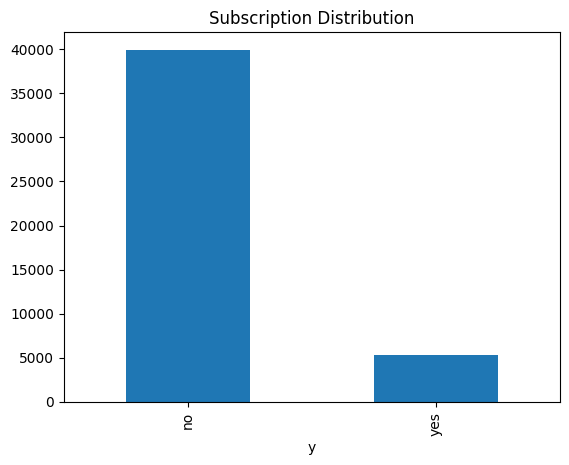

In [15]:
import matplotlib.pyplot as plt

df['y'].value_counts().plot(kind='bar')
plt.title('Subscription Distribution')
plt.show()

Helps identify the most represented age groups and detect any unusual age values or skewness in the data.

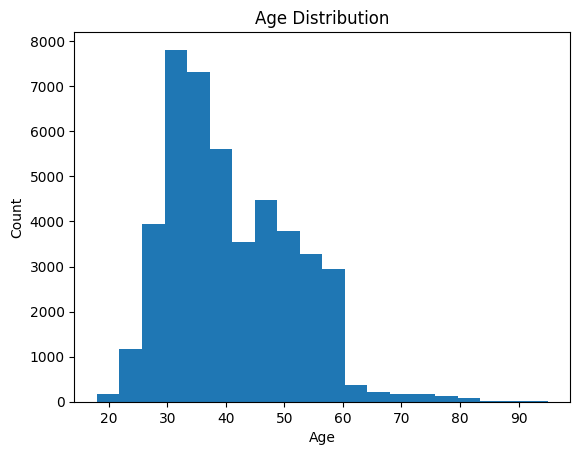

In [16]:
plt.hist(df['age'], bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

:

▶ box plot to visualize the distribution of account balances and identify potential outliers.

*Customer balances shows noticeable outliers, which is common in financial datasets. Tree-based models may handle these well, while the logistic regression may require scaling or outlier treatment.*

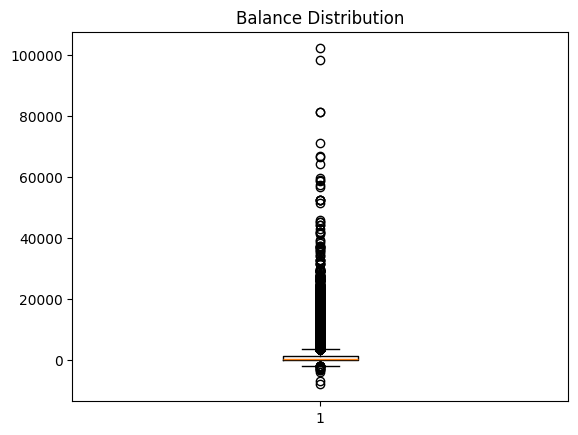

In [17]:
plt.boxplot(df['balance'])
plt.title('Balance Distribution')
plt.show()

A correlation heatmap generated for numerical features to examine linear relationships between variables.

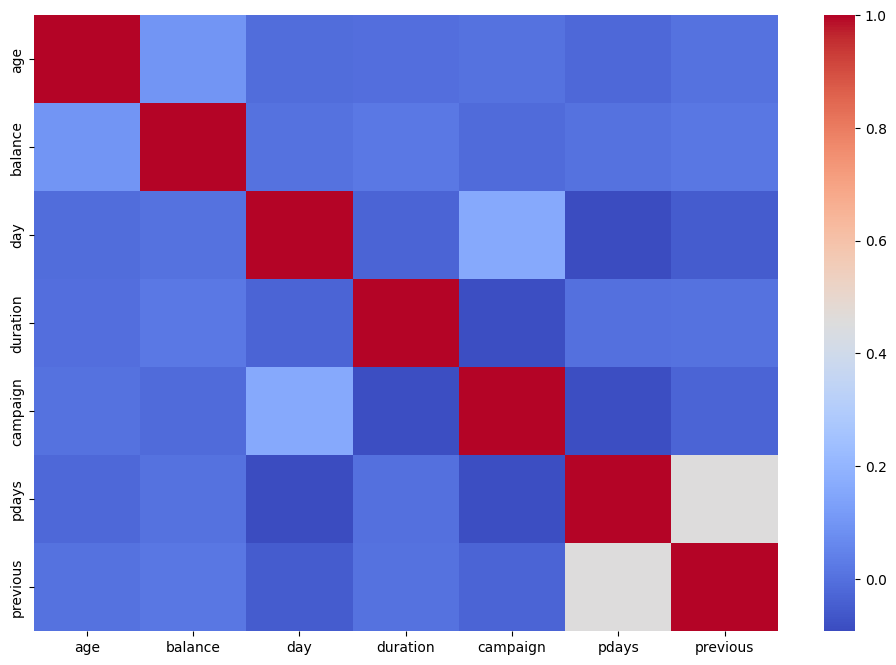

In [19]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

 count plot used to visualize the number of customers in each occupation.

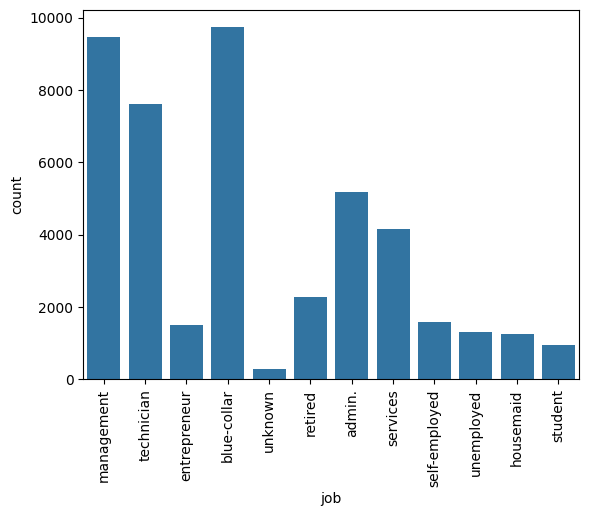

In [20]:
sns.countplot(x='job', data=df)
plt.xticks(rotation=90)
plt.show()

Count plots created for major categorical variables with the target variable (y) as the hue to compare subscription behavior across categories.

*this indicates that the variables such as job, education, housing loan, contact type, month, and previous campaign outcome may be useful predictors.

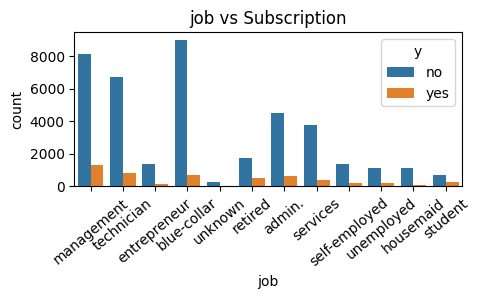

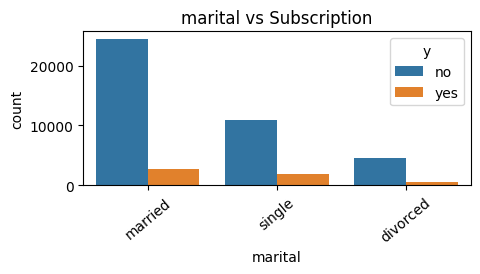

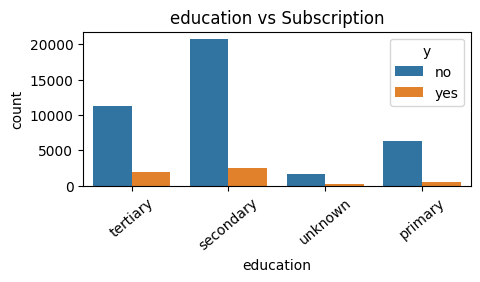

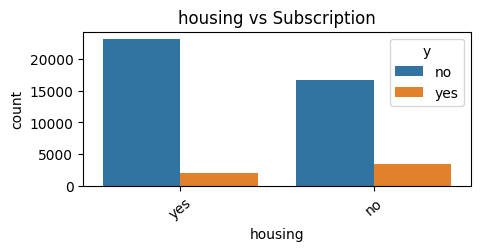

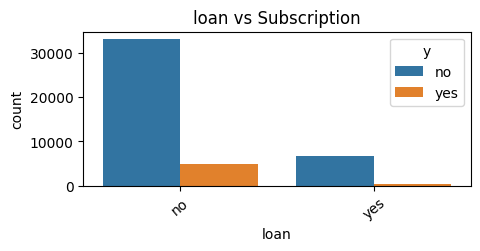

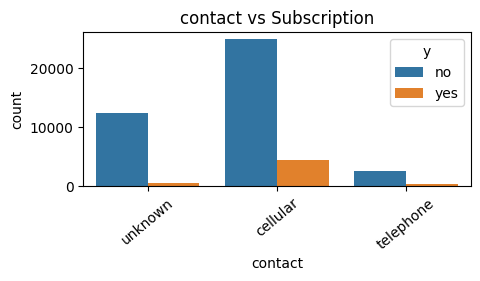

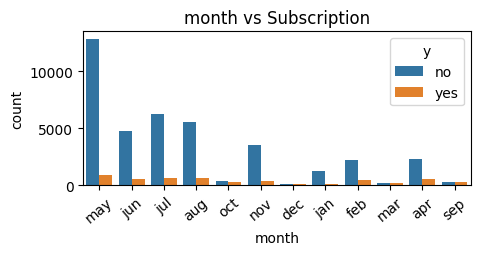

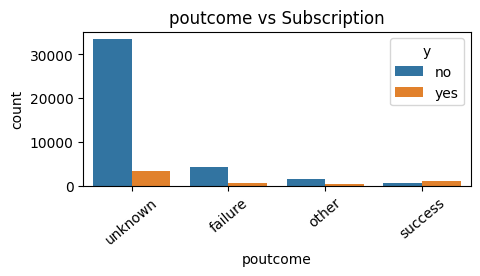

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

catgs = ['job', 'marital', 'education', 'housing',
            'loan', 'contact', 'month', 'poutcome']

for col in catgs:
    plt.figure(figsize=(5,2))
    sns.countplot(x=col, hue='y', data=df)
    plt.xticks(rotation=40)
    plt.title(f'{col} vs Subscription')
    plt.show()

#:box plot for balance distributions helps determine whether customers with different account balances has different subscription pattern, making balance a potentially informative feature.

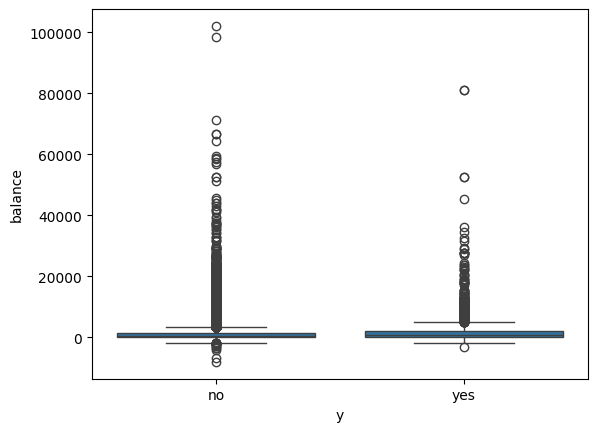

In [22]:
sns.boxplot(x='y', y='balance', data=df)
plt.show()

**Encoding**

catagorical variables converted into numerical while binary variables encoded into 0 and 1.

The ml models can process now while preserving the information contained in each category.

In [77]:
df2 = pd.get_dummies(
    df2,
    columns=['job','marital','education','contact','month','poutcome'],
    drop_first=True
)

In [78]:
yes_no_cols = ['default','housing','loan']

for col in yes_no_cols:
    df2[col] = df2[col].map({'no':0, 'yes':1})

In [79]:
df2

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,261,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
1,44,0,29,1,0,5,151,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
2,33,0,2,1,1,5,76,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
3,47,0,1506,1,0,5,92,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
4,33,0,1,0,0,5,198,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,0,825,0,0,17,977,3,-1,0,...,False,False,False,False,True,False,False,False,False,True
45207,71,0,1729,0,0,17,456,2,-1,0,...,False,False,False,False,True,False,False,False,False,True
45208,72,0,5715,0,0,17,1127,5,184,3,...,False,False,False,False,True,False,False,False,True,False
45209,57,0,668,0,0,17,508,4,-1,0,...,False,False,False,False,True,False,False,False,False,True


In [43]:
df_final=df2.copy()

In [44]:
df_final['y'] = df['y'].map({'no':0, 'yes':1})

In [45]:
df_final['y']

,y
0,0
1,0
2,0
3,0
4,0
...,...
45206,1
45207,1
45208,1
45209,0


**Feature Selection and Train-Test Split**

The target variable (y)  separated from the  variables (X). The dataset was then divided into 80% training set and 20% testing set using train_test_split().

now the data is ready for the model and evaluation.

---



In [46]:
X = df_final.drop('y', axis=1)
y = df_final['y']

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

**Model training and evaluation**

Random forest classifier

In [49]:
from sklearn.ensemble import RandomForestClassifier

rfmodel = RandomForestClassifier(random_state=42)

rfmodel.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [50]:
y_pred = rfmodel.predict(X_test)

In [51]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix for rfmodel:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report for rfmodel:")
print(classification_report(y_test, y_pred))

Confusion Matrix for rfmodel:
[[7754  198]
 [ 661  430]]

Classification Report for rfmodel:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7952
           1       0.68      0.39      0.50      1091

    accuracy                           0.91      9043
   macro avg       0.80      0.68      0.72      9043
weighted avg       0.89      0.91      0.89      9043



In [52]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9050093995355524

Accuracy alone should not be the primary evaluation metric because the dataset is imbalanced. The confusion matrix and classification report provide a more comprehensive assessment of how well the model identifies both subscribers and non-subscribers.

**Random Forest with Balanced Class Weights**

In [53]:
rf_balanced = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_balanced.fit(X_train, y_train)

rf_balanced_pred = rf_balanced.predict(X_test)

the balanced model showed a slight decrease in accuracy (91% → 90%), recall for the subscriber class (39% → 33%), and F1-score (0.50 → 0.45). Therefore, the default Random Forest model was better suited for this dataset.

In [54]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix for rf_balanced
print("Confusion Matrix for rf_balanced:")
print(confusion_matrix(y_test, rf_balanced_pred))

# Classification Report for rf_balanced
print("\nClassification Report for rf_balanced:")
print(classification_report(y_test, rf_balanced_pred))

Confusion Matrix for rf_balanced:
[[7803  149]
 [ 728  363]]

Classification Report for rf_balanced:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7952
           1       0.71      0.33      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.81      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



**Hyperparameter-Tuned Random Forest**

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

rf_tuned_pred = rf_tuned.predict(X_test)

Despite tuning the hyperparameters, the model performed slightly worse than the baseline Random Forest. This makes the default model as the preferred Random Forest model for the given data.

In [56]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix for rf_tuned
print("Confusion Matrix for rf_tuned:")
print(confusion_matrix(y_test, rf_tuned_pred))

# Classification Report for rf_tuned
print("\nClassification Report for rf_tuned:")
print(classification_report(y_test, rf_tuned_pred))

Confusion Matrix for rf_tuned:
[[7794  158]
 [ 737  354]]

Classification Report for rf_tuned:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7952
           1       0.69      0.32      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.80      0.65      0.69      9043
weighted avg       0.89      0.90      0.88      9043



**Feature scaling the numerical columns**

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Create copies
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Numerical columns only
num_cols = ['age', 'balance', 'day', 'duration',
            'campaign', 'pdays', 'previous']

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

**Training with logistic regression**

logistic Regression provides a useful benchmark for comparing the performance of a linear model against a tree-based ensemble model.

In [58]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

In [59]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, lr_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8988167643481145


In [60]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix for Logistic Regression:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, lr_pred))

Confusion Matrix for Logistic Regression:
[[7756  196]
 [ 719  372]]

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.98      0.94      7952
           1       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



**Logistic regression-Balanced weights**

In [61]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(
    random_state=42,
    class_weight='balanced'
)

lr_balanced.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [62]:
lr_balanced_pred = lr_balanced.predict(X_test_scaled)

Logistic Regression achieved an accuracy of 84.23%, lower than Random Forest (91%), but significantly improved recall by identifying more customers who subscribed. This came at the cost of lower precision (42%) and more false positives. Therefore, Logistic Regression is a suitable choice when maximizing the detection of potential subscribers is more important than overall accuracy.

*This is a strongly demonstrates the "best" model depends on the business objective, not just the highest accuracy.*

In [64]:
print("Accuracy:", accuracy_score(y_test, lr_balanced_pred))

print(confusion_matrix(y_test, lr_balanced_pred))

print(classification_report(y_test, lr_balanced_pred))

Accuracy: 0.8423089682627447
[[6711 1241]
 [ 185  906]]
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7952
           1       0.42      0.83      0.56      1091

    accuracy                           0.84      9043
   macro avg       0.70      0.84      0.73      9043
weighted avg       0.91      0.84      0.86      9043



**The feature importance scores from the trained Random Forest model**

In [65]:

importance = pd.Series(
    rfmodel.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

duration               0.274977
balance                0.100906
age                    0.099861
day                    0.086811
poutcome_success       0.053275
pdays                  0.042150
campaign               0.039097
previous               0.021703
housing                0.021448
contact_unknown        0.014095
education_secondary    0.013018
month_mar              0.012518
marital_married        0.011767
education_tertiary     0.011527
job_technician         0.011166
job_management         0.010760
month_oct              0.010640
month_jun              0.010638
month_aug              0.010493
marital_single         0.010256
month_may              0.010121
month_jul              0.009860
loan                   0.009672
job_blue-collar        0.008749
month_nov              0.008673
month_feb              0.008349
month_sep              0.008206
contact_telephone      0.007355
job_services           0.006827
poutcome_unknown       0.006130
education_unknown      0.005506
job_reti

the features ranked in descending order to identify the variables that contributed most to the model's predictions.

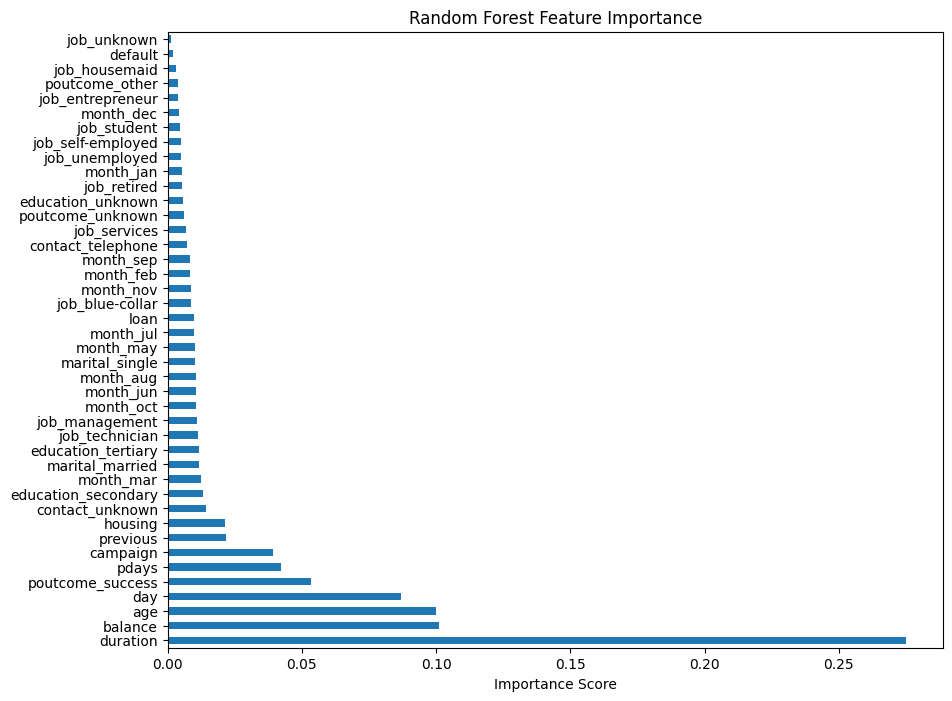

In [66]:
import matplotlib.pyplot as plt

importance.plot(kind='barh', figsize=(10,8))

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

**An experiment with droping the column(default) having lowest feature importance**

found a slight improvement in the overall performance.

In [67]:
# Original data
X_train
X_test

# New experiment
X_train_no_default = X_train.drop('default', axis=1)
X_test_no_default = X_test.drop('default', axis=1)

rf_no_default = RandomForestClassifier(random_state=42)
rf_no_default.fit(X_train_no_default, y_train)

rf_no_default_pred = rf_no_default.predict(X_test_no_default)

In [68]:
accuracy_score(y_test, rf_no_default_pred)

print(confusion_matrix(y_test, rf_no_default_pred))

print(classification_report(y_test, rf_no_default_pred))

[[7730  222]
 [ 651  440]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.66      0.40      0.50      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.69      0.72      9043
weighted avg       0.89      0.90      0.89      9043



**Cross-Validation: A 5-fold cross-validation was performed on the final Random Forest model. The model achieved a mean accuracy of 90.38% indicating stable and consistent performance across different data splits.**

In [69]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rfmodel, X_train, y_train, cv=5)
print(scores)
print("Mean Accuracy:", scores.mean())

[0.90254354 0.90378767 0.90226707 0.90529517 0.90529517]
Mean Accuracy: 0.9038377271315948


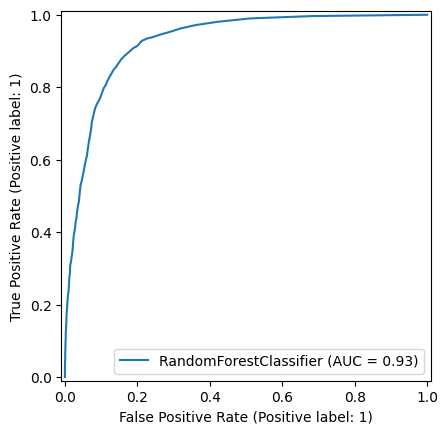

In [70]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rfmodel, X_test, y_test)
plt.show()

In [71]:
from sklearn.metrics import roc_auc_score

y_prob = rfmodel.predict_proba(X_test)[:,1]

print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.9263291711773851


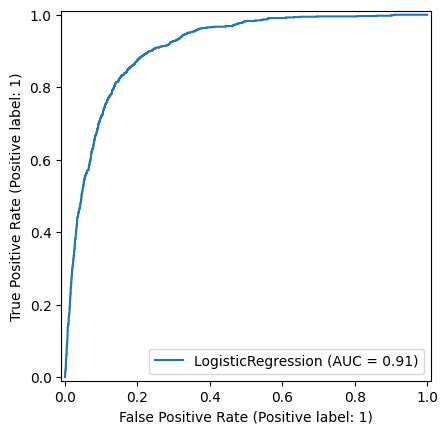

In [72]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(lr_balanced, X_test_scaled, y_test)
plt.show()

In [73]:
from sklearn.metrics import roc_auc_score

y_prob = lr_balanced.predict_proba(X_test_scaled)[:,1]

print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.9079427297054555


In [74]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Random Forest", "Balanced Logistic Regression"],
    "Accuracy": [0.905, 0.842],
    "Precision": [0.68, 0.42],   # Class 1
    "Recall": [0.39, 0.83],      # Class 1
    "F1-score": [0.50, 0.56],    # Class 1
    "AUC": [0.926, 0.908]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score,AUC
0,Random Forest,0.905,0.68,0.39,0.50,0.926
1,Balanced Logistic Regression,0.842,0.42,0.83,0.56,0.908


:Interpretation

#Random Forest

*Highest overall accuracy.

*Best AUC (0.926).

 *Stable performance (5-fold CV ≈ 90.4%).

*Captures complex, non-linear patterns.

*Misses a portion of positive cases (moderate recall).

#Balanced Logistic Regression
*Better suited for handling the imbalanced dataset.

*Typically improves recall for the minority class.

*Simpler and more interpretable model.
*Slightly lower overall discrimination (AUC 0.908) than Random Forest.

# **`conclusion`**
#Built and evaluated Random Forest and Balanced Logistic Regression models for predicting term deposit subscriptions.
#Random Forest achieved performance with 90.5% accuracy and an AUC of 0.926.
#Balanced Logistic Regression achieved higher recall, making it better at identifying potential subscribers but with lower overall accuracy.
#Duration, balance, age, and previous campaign outcome were the most influential features.
#The final model can help banks identify potential customers and improve the efficiency of future marketing campaigns.